# Patient Satisfaction Prediction from Hospital Reviews
## IE 7275 - Data Mining in Engineering
### Wiktoria Lasek

---

## Section 1: Setup
Importing all required libraries for data loading, preprocessing, modelling and evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import train_test_split
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
warnings.filterwarnings('ignore')

print("Libraries imported!")

Libraries imported!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Libraries loaded successfully.

## Section 2: Data Loading and Exploration

### 2.1 Loading Dataset
Loading the Hospital Patient Reviews dataset from Kaggle.
996 rows, 3 columns: Feedback, Sentiment Label, Ratings

In [2]:
hospital_df = pd.read_csv('hospital.csv')
hospital_df = hospital_df.drop(columns=['Unnamed: 3'])

print(f"Shape: {hospital_df.shape}")
print(f"Columns: {hospital_df.columns.tolist()}")
hospital_df.head()

Shape: (996, 3)
Columns: ['Feedback', 'Sentiment Label', 'Ratings']


,Feedback,Sentiment Label,Ratings
0,Good and clean hospital. There is great team o...,1,5
1,Had a really bad experience during discharge. ...,1,5
2,I have visited to take my second dose and Proc...,1,4
3,That person was slightly clueless and offered...,1,3
4,There is great team of doctors and good OT fac...,0,1


### Findings:
- Shape: (996, 3)
- Columns: Feedback, Sentiment Label, Ratings

In [3]:
print("Missing values:")
print(hospital_df.isnull().sum())
print(f"Total missing: {hospital_df.isnull().sum().sum()}")

Missing values:
Feedback           0
Sentiment Label    0
Ratings            0
dtype: int64
Total missing: 0


### Findings:
- Zero missing values across all columns
- Dataset is completely clean - no imputation needed

In [4]:
print("Label distribution:")
print(hospital_df['Sentiment Label'].value_counts())
print(f"\nPositive: {hospital_df['Sentiment Label'].sum()} ({hospital_df['Sentiment Label'].mean()*100:.1f}%)")
print(f"Negative: {(hospital_df['Sentiment Label']==0).sum()} ({(1-hospital_df['Sentiment Label'].mean())*100:.1f}%)")

Label distribution:
Sentiment Label
1    728
0    268
Name: count, dtype: int64

Positive: 728 (73.1%)
Negative: 268 (26.9%)


### Findings:
- Imbalanced dataset - 728 positive (73.1%), 268 negative (26.9%)
- F1-score will be used as primary metric due to class imbalance

In [5]:
hospital_df['review_length'] = hospital_df['Feedback'].apply(lambda x: len(str(x).split()))
print("Review length statistics:")
print(hospital_df['review_length'].describe())

Review length statistics:
count    996.000000
mean      20.479920
std       10.473542
min        1.000000
25%       14.000000
50%       19.000000
75%       25.000000
max      149.000000
Name: review_length, dtype: float64


### Findings:
- Mean review length: 20 words, median: 19 words
- Reviews are very short - influences TF-IDF feature selection
- Max length: 149 words

In [6]:
X = hospital_df['Feedback']
y = hospital_df['Sentiment Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]} reviews")
print(f"Test set: {X_test.shape[0]} reviews")
print(f"\nTrain label distribution:")
print(y_train.value_counts())
print(f"\nTest label distribution:")
print(y_test.value_counts())

Training set: 796 reviews
Test set: 200 reviews

Train label distribution:
Sentiment Label
1    582
0    214
Name: count, dtype: int64

Test label distribution:
Sentiment Label
1    146
0     54
Name: count, dtype: int64


### 2.2 Train/Test Split
- Training set: 796 reviews (582 positive, 214 negative)
- Test set: 200 reviews (146 positive, 54 negative)
- Stratified split - class balance maintained

## Section 3: Text Preprocessing and Feature Engineering

### 3.1 Text Preprocessing
Applying heavy text cleaning:
- Convert to lowercase
- Remove punctuation and special characters
- Remove stop words

In [7]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.strip()
    words = text.split()
    words = [w for w in words if w not in stop_words]
    text = ' '.join(words)
    return text

X_train_clean = X_train.apply(clean_text)
X_test_clean = X_test.apply(clean_text)

print("Text preprocessing done!")
print("\nOriginal review:")
print(X_train.iloc[0])
print("\nCleaned review:")
print(X_train_clean.iloc[0])

Text preprocessing done!

Original review:
Worst facility no proper treatment provided to the patient and before estimated the bill will be limited to the extend and post that itâ€™s gonna be double and triple for unwanted test been performed

Cleaned review:
worst facility proper treatment provided patient estimated bill limited extend post gonna double triple unwanted test performed


### Findings:
- Text cleaned successfully
- Stop words removed - only meaningful sentiment words remain

### 3.2 TF-IDF Feature Extraction
Converting cleaned text to numerical features using TF-IDF vectorization.
- max_features=500 - suitable for short reviews (mean 20 words)
- Fitted on training data only - test data transformed using same vocabulary

In [8]:
tfidf = TfidfVectorizer(max_features=500)
X_train_tfidf = tfidf.fit_transform(X_train_clean)
X_test_tfidf = tfidf.transform(X_test_clean)

print(f"X_train_tfidf shape: {X_train_tfidf.shape}")
print(f"X_test_tfidf shape: {X_test_tfidf.shape}")

X_train_tfidf shape: (796, 500)
X_test_tfidf shape: (200, 500)


### Findings:
- X_train shape: (796, 500)
- X_test shape: (200, 500)

### 3.3 Feature Selection (Chi-Squared)
Reducing from 500 to 200 most statistically significant features.
This removes noise and improves model efficiency.

In [9]:
selector = SelectKBest(chi2, k=200)
X_train_selected = selector.fit_transform(X_train_tfidf, y_train)
X_test_selected = selector.transform(X_test_tfidf)

print(f"After feature selection:")
print(f"X_train shape: {X_train_selected.shape}")
print(f"X_test shape: {X_test_selected.shape}")

# Show top 10 most important features
feature_names = tfidf.get_feature_names_out()
selected_mask = selector.get_support()
selected_features = feature_names[selected_mask]
print(f"\nTop 10 selected features:")
print(selected_features[:10])

After feature selection:
X_train shape: (796, 200)
X_test shape: (200, 200)

Top 10 selected features:
['admit' 'amazing' 'anything' 'appointment' 'appointments' 'appreciate'
 'arrogant' 'ask' 'aster' 'attentive']


### Findings:
- Reduced from 500 -> 200 features
- Top selected features include: admit, amazing, appointment, arrogant, attentive

## Section 4: Model Building and Evaluation
Training and comparing 5 classification models.
F1-Score is used as primary metric due to class imbalance.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_selected, y_train)

lr_preds = lr_model.predict(X_test_selected)
lr_accuracy = accuracy_score(y_test, lr_preds)
lr_f1 = f1_score(y_test, lr_preds)

print(f"\n LOGISTIC REGRESSION RESULTS ")
print(f"Accuracy: {lr_accuracy:.4f}")
print(f"F1-Score: {lr_f1:.4f}")
print(classification_report(y_test, lr_preds))


 LOGISTIC REGRESSION RESULTS 
Accuracy: 0.8250
F1-Score: 0.8903
              precision    recall  f1-score   support

           0       0.85      0.43      0.57        54
           1       0.82      0.97      0.89       146

    accuracy                           0.82       200
   macro avg       0.84      0.70      0.73       200
weighted avg       0.83      0.82      0.80       200



### LR Results:
- Accuracy: 82.50% | F1-Score: 89.03%
- Strong baseline - high recall for positive class (0.97)
- Low recall for negative class (0.43) - due to class imbalance

In [11]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train_selected, y_train)

nb_preds = nb_model.predict(X_test_selected)
nb_accuracy = accuracy_score(y_test, nb_preds)
nb_f1 = f1_score(y_test, nb_preds)

print(f"\n NAIVE BAYES RESULTS")
print(f"Accuracy: {nb_accuracy:.4f}")
print(f"F1-Score: {nb_f1:.4f}")
print(classification_report(y_test, nb_preds))


 NAIVE BAYES RESULTS
Accuracy: 0.8250
F1-Score: 0.8889
              precision    recall  f1-score   support

           0       0.81      0.46      0.59        54
           1       0.83      0.96      0.89       146

    accuracy                           0.82       200
   macro avg       0.82      0.71      0.74       200
weighted avg       0.82      0.82      0.81       200



### Naive Bayes Results:
- Accuracy: 82.50% | F1-Score: 88.89%
- Similar performance to LR
- Fast and effective for text classification

In [12]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_selected, y_train)

dt_preds = dt_model.predict(X_test_selected)
dt_accuracy = accuracy_score(y_test, dt_preds)
dt_f1 = f1_score(y_test, dt_preds)

print(f"\n DECISION TREE RESULTS ")
print(f"Accuracy: {dt_accuracy:.4f}")
print(f"F1-Score: {dt_f1:.4f}")
print(classification_report(y_test, dt_preds))


 DECISION TREE RESULTS 
Accuracy: 0.7950
F1-Score: 0.8620
              precision    recall  f1-score   support

           0       0.63      0.57      0.60        54
           1       0.85      0.88      0.86       146

    accuracy                           0.80       200
   macro avg       0.74      0.73      0.73       200
weighted avg       0.79      0.80      0.79       200



### Decision Tree Results:
- Accuracy: 79.50% | F1-Score: 86.20%
- Worst performing model - as expected due to overfitting on small datasets

In [13]:
from sklearn.svm import SVC

svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_selected, y_train)

svm_preds = svm_model.predict(X_test_selected)
svm_accuracy = accuracy_score(y_test, svm_preds)
svm_f1 = f1_score(y_test, svm_preds)

print(f"\n SVM RESULTS ")
print(f"Accuracy: {svm_accuracy:.4f}")
print(f"F1-Score: {svm_f1:.4f}")
print(classification_report(y_test, svm_preds))


 SVM RESULTS 
Accuracy: 0.8350
F1-Score: 0.8946
              precision    recall  f1-score   support

           0       0.82      0.50      0.62        54
           1       0.84      0.96      0.89       146

    accuracy                           0.83       200
   macro avg       0.83      0.73      0.76       200
weighted avg       0.83      0.83      0.82       200



### SVM Results:
- Accuracy: 83.50% | F1-Score: 89.46%
- Best performing model
- Highest accuracy and F1-score across all models

In [14]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_selected, y_train)

knn_preds = knn_model.predict(X_test_selected)
knn_accuracy = accuracy_score(y_test, knn_preds)
knn_f1 = f1_score(y_test, knn_preds)

print(f"\n KNN RESULTS ")
print(f"Accuracy: {knn_accuracy:.4f}")
print(f"F1-Score: {knn_f1:.4f}")
print(classification_report(y_test, knn_preds))


 KNN RESULTS 
Accuracy: 0.8050
F1-Score: 0.8746
              precision    recall  f1-score   support

           0       0.71      0.46      0.56        54
           1       0.82      0.93      0.87       146

    accuracy                           0.81       200
   macro avg       0.77      0.70      0.72       200
weighted avg       0.79      0.81      0.79       200



### KNN Results:
- Accuracy: 80.50% | F1-Score: 87.46%
- Moderate performance
- Sensitive to class imbalance

In [15]:
from sklearn.model_selection import cross_val_score

print(" 5-FOLD CROSS VALIDATION \n")

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes': MultinomialNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(kernel='linear', random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

for name, model in models.items():
    scores = cross_val_score(model, X_train_selected, y_train, cv=5, scoring='f1')
    print(f"{name}:")
    print(f"  F1 scores: {scores.round(4)}")
    print(f"  Mean F1: {scores.mean():.4f} (+/- {scores.std():.4f})\n")

 5-FOLD CROSS VALIDATION 

Logistic Regression:
  F1 scores: [0.8819 0.8837 0.8898 0.9268 0.8669]
  Mean F1: 0.8898 (+/- 0.0200)

Naive Bayes:
  F1 scores: [0.88   0.8933 0.9004 0.9218 0.8898]
  Mean F1: 0.8971 (+/- 0.0140)

Decision Tree:
  F1 scores: [0.8696 0.8816 0.8824 0.8559 0.837 ]
  Mean F1: 0.8653 (+/- 0.0171)

SVM:
  F1 scores: [0.8862 0.8898 0.918  0.9198 0.873 ]
  Mean F1: 0.8974 (+/- 0.0185)

KNN:
  F1 scores: [0.8682 0.8582 0.8803 0.8661 0.8473]
  Mean F1: 0.8640 (+/- 0.0109)



### 5-Fold Cross Validation Results:
- SVM: Mean F1 = 0.8974 - best and most consistent
- Naive Bayes: Mean F1 = 0.8971 - close second
- Logistic Regression: Mean F1 = 0.8898
- Decision Tree: Mean F1 = 0.8653 - worst
- KNN: Mean F1 = 0.8640

In [16]:
print("FINAL MODEL COMPARISON")
print(f"{'Model':<25} {'Accuracy':>10} {'F1-Score':>10}")
print("-" * 50)
print(f"{'Logistic Regression':<25} {lr_accuracy:>10.4f} {lr_f1:>10.4f}")
print(f"{'Naive Bayes':<25} {nb_accuracy:>10.4f} {nb_f1:>10.4f}")
print(f"{'Decision Tree':<25} {dt_accuracy:>10.4f} {dt_f1:>10.4f}")
print(f"{'SVM':<25} {svm_accuracy:>10.4f} {svm_f1:>10.4f}")
print(f"{'KNN':<25} {knn_accuracy:>10.4f} {knn_f1:>10.4f}")

FINAL MODEL COMPARISON
Model                       Accuracy   F1-Score
--------------------------------------------------
Logistic Regression           0.8250     0.8903
Naive Bayes                   0.8250     0.8889
Decision Tree                 0.7950     0.8620
SVM                           0.8350     0.8946
KNN                           0.8050     0.8746


## Section 5: Conclusions

### Key Findings:
- SVM achieves the best performance - highest accuracy (83.50%) and F1-score (89.46%)
- All models struggle with the negative class due to class imbalance (73/27)
- Decision Tree performs worst - prone to overfitting on small datasets
- Cross validation confirms SVM and Naive Bayes are the most reliable models



## Section 5: Performance Visualization

### 5.1 Model Accuracy and F1-Score Comparison
Comparing accuracy and F1-score across all 5 models visually.
F1-score is consistently higher than accuracy due to class imbalance.

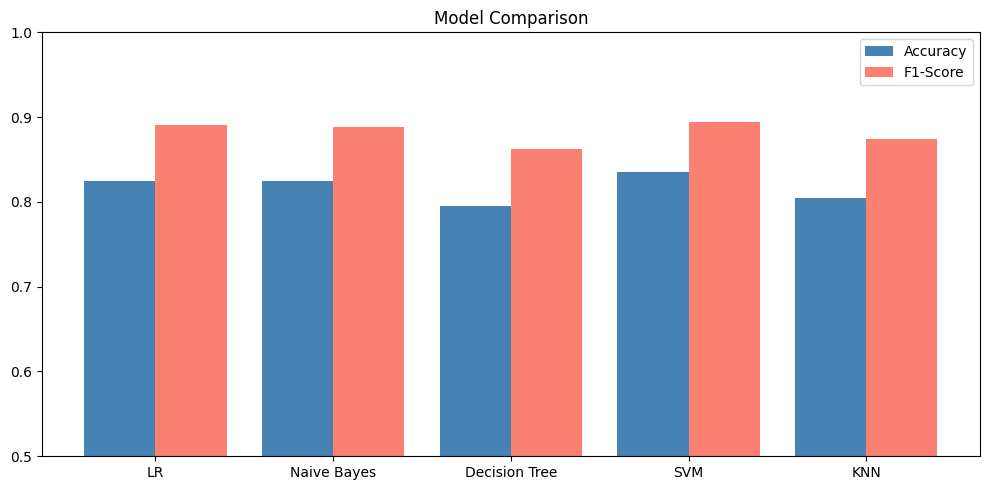

In [17]:
import matplotlib.pyplot as plt

models = ['LR', 'Naive Bayes', 'Decision Tree', 'SVM', 'KNN']
accuracies = [lr_accuracy, nb_accuracy, dt_accuracy, svm_accuracy, knn_accuracy]
f1_scores = [lr_f1, nb_f1, dt_f1, svm_f1, knn_f1]

plt.figure(figsize=(10, 5))
x = range(len(models))
plt.bar([i - 0.2 for i in x], accuracies, width=0.4, label='Accuracy', color='steelblue')
plt.bar([i + 0.2 for i in x], f1_scores, width=0.4, label='F1-Score', color='salmon')
plt.xticks(x, models)
plt.ylim(0.5, 1.0)
plt.title('Model Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('model_comparison_7275_project.png')
plt.show()

### Findings:
- SVM achieves highest accuracy (83.50%)
- LR and SVM achieve highest F1-scores
- Decision Tree performs worst across both metrics
- F1-scores are higher than accuracy for all models - expected with imbalanced data

### 5.2 Confusion Matrices
Showing true positives, true negatives, false positives and false negatives for each model.

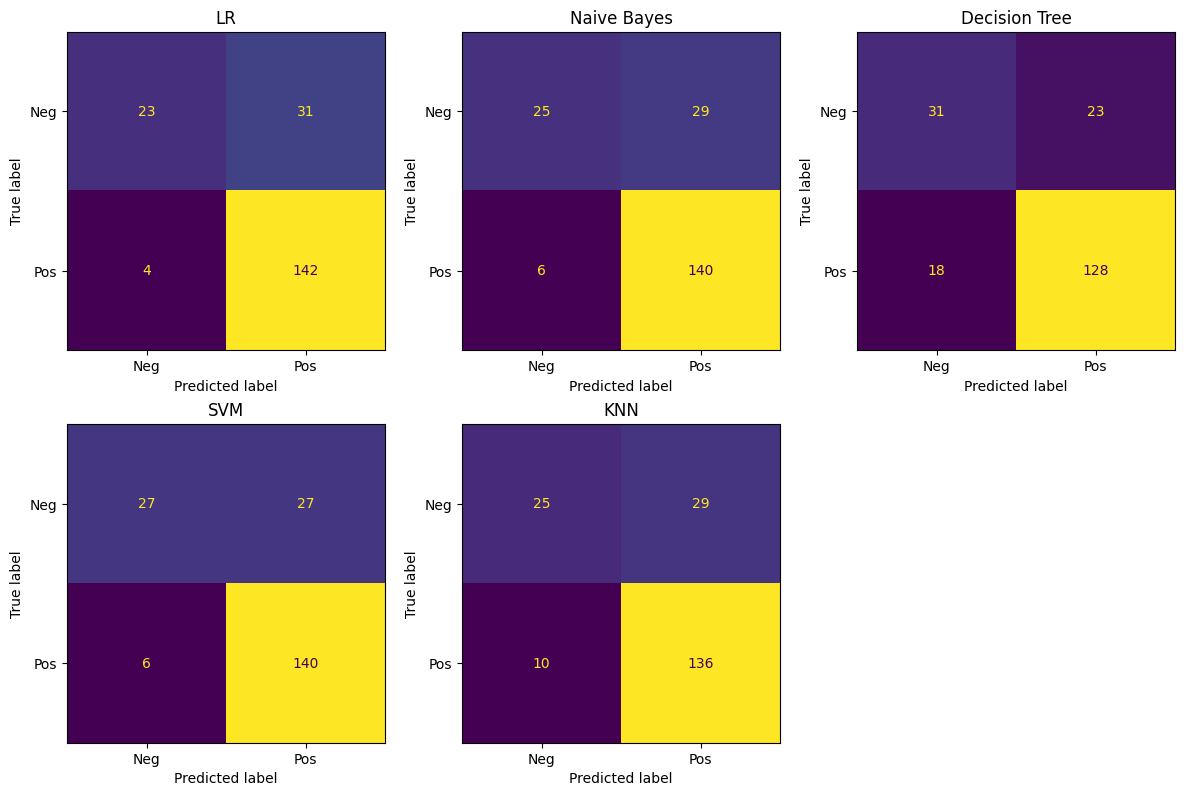

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

all_preds = [lr_preds, nb_preds, dt_preds, svm_preds, knn_preds]
all_names = ['LR', 'Naive Bayes', 'Decision Tree', 'SVM', 'KNN']

for i, (preds, name) in enumerate(zip(all_preds, all_names)):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=['Neg', 'Pos']).plot(ax=axes[i], colorbar=False)
    axes[i].set_title(name)

axes[5].axis('off')
plt.tight_layout()
plt.savefig('confusion_matrices_7275_project.png')
plt.show()

### Findings:
- All models struggle with negative class (low true negatives)
- SVM correctly identifies 27 negative reviews - best among all models
- LR and Naive Bayes miss many negative reviews (high false negatives)
- Class imbalance clearly visible - models favour positive class

### 5.3 ROC Curves
ROC curves show how well each model separates positive from negative reviews.
A higher AUC (Area Under Curve) means better overall discrimination ability.

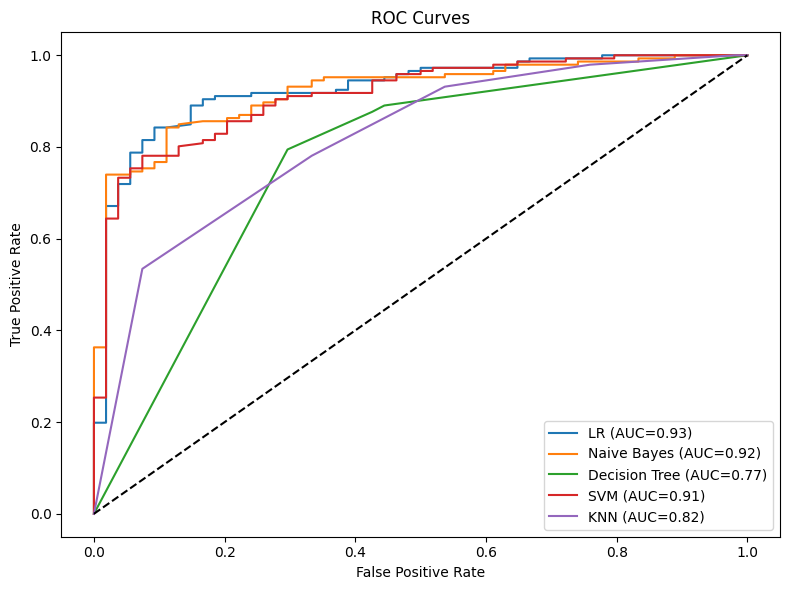

In [19]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))

models_roc = {
    'LR': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes': MultinomialNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(kernel='linear', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

for name, model in models_roc.items():
    model.fit(X_train_selected, y_train)
    y_prob = model.predict_proba(X_test_selected)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc(fpr,tpr):.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curves_7275_project.png')
plt.show()

### Findings:
- LR achieves highest AUC = 0.93
- Naive Bayes AUC = 0.92 - close second
- SVM AUC = 0.91
- KNN AUC = 0.82
- Decision Tree worst AUC = 0.77
- Interesting: LR has best AUC but SVM has best F1 - LR ranks predictions better while SVM classifies them better

### 5.4 5-Fold Cross Validation F1-Score
Showing mean F1-score from 5-fold cross validation - more reliable than single test set evaluation.

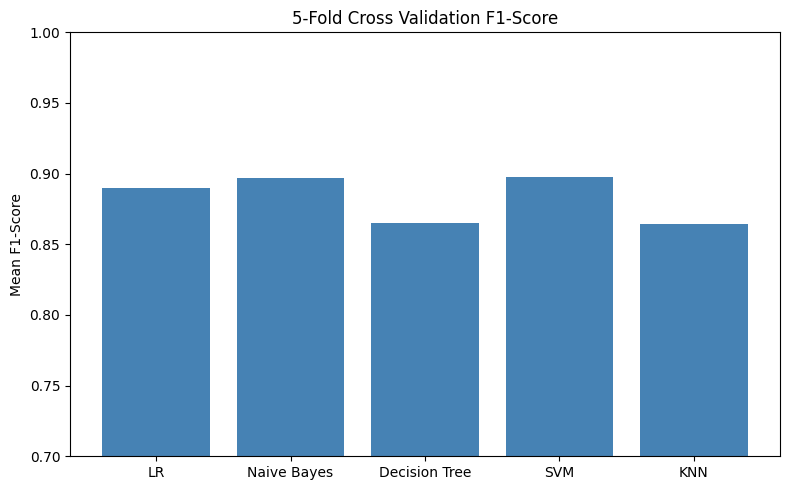

In [20]:
from sklearn.model_selection import cross_val_score

models_cv = {
    'LR': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes': MultinomialNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(kernel='linear', random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

means = [cross_val_score(m, X_train_selected, y_train, cv=5, scoring='f1').mean()
         for m in models_cv.values()]

plt.figure(figsize=(8, 5))
plt.bar(models_cv.keys(), means, color='steelblue')
plt.ylim(0.7, 1.0)
plt.title('5-Fold Cross Validation F1-Score')
plt.ylabel('Mean F1-Score')
plt.tight_layout()
plt.savefig('cross_validation.png')
plt.show()

### Findings:
- SVM mean F1 = 0.8974 - most reliable model
- Naive Bayes mean F1 = 0.8971 - very close to SVM
- LR mean F1 = 0.8898
- Decision Tree mean F1 = 0.8653
- KNN mean F1 = 0.8640 - least consistent
- Cross validation confirms SVM as the best overall model